In [35]:

import pandas as pd

# Load Dataset
df = pd.read_csv("Housing.csv")

# --------------------------------------------------
# First 10 Rows
# --------------------------------------------------
print("\nFIRST 10 ROWS")
print("-" * 50)
display(df.head(10))

# --------------------------------------------------
# Dataset Shape
# --------------------------------------------------
print("\nDATASET SHAPE")
print("-" * 50)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# --------------------------------------------------
# Target & Features
# --------------------------------------------------
target = "price"
features = [col for col in df.columns if col != target]

print("\nTARGET VARIABLE")
print("-" * 50)
print(target)

print("\nFEATURE COLUMNS")
print("-" * 50)
for col in features:
    print(col)

# Data Types
print("\nDATA TYPES")
print("-" * 50)
display(df.dtypes.to_frame(name="Data Type"))

# --------------------------------------------------
# Missing Values
# --------------------------------------------------
print("\nMISSING VALUES")
print("-" * 50)
display(df.isnull().sum().to_frame(name="Missing Values"))

# Duplicate Rows
print("\nDUPLICATE ROWS")
print("-" * 50)
print(df.duplicated().sum())


# Statistical Summary
print("\nSTATISTICAL SUMMARY")
print("-" * 50)
display(df.describe())


FIRST 10 ROWS
--------------------------------------------------


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



DATASET SHAPE
--------------------------------------------------
Rows    : 545
Columns : 13

TARGET VARIABLE
--------------------------------------------------
price

FEATURE COLUMNS
--------------------------------------------------
area
bedrooms
bathrooms
stories
mainroad
guestroom
basement
hotwaterheating
airconditioning
parking
prefarea
furnishingstatus

DATA TYPES
--------------------------------------------------


,Data Type
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,str
guestroom,str
basement,str
hotwaterheating,str
airconditioning,str



MISSING VALUES
--------------------------------------------------


,Missing Values
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0



DUPLICATE ROWS
--------------------------------------------------
0

STATISTICAL SUMMARY
--------------------------------------------------


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [13]:

#Data Cleaning
print("\nDATA CLEANING")
print("-" * 50)

# Check duplicates before removal
print("Duplicate Rows Before Cleaning:")
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check missing values
print("\nMissing Values Before Cleaning:")
display(df.isnull().sum().to_frame(name="Missing Values"))

# Remove missing values
df.dropna(inplace=True)

print("\nDataset Shape After Cleaning:")
print(df.shape)


DATA CLEANING
--------------------------------------------------
Duplicate Rows Before Cleaning:
0

Missing Values Before Cleaning:


,Missing Values
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0



Dataset Shape After Cleaning:
(545, 13)


In [21]:

# ENCODING CATEGORICAL VARIABLES
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({'yes':1,'no':0})

print("Binary Columns Encoded Successfully")

Binary Columns Encoded Successfully


In [22]:
# One Hot Encoding

df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Columns:")
display(pd.DataFrame(df.columns, columns=["Columns"]))


Final Dataset Shape:
(545, 14)

Final Columns:


,Columns
0,price
1,area
2,bedrooms
3,bathrooms
4,stories
5,mainroad
6,guestroom
7,basement
8,hotwaterheating
9,airconditioning


In [23]:
#splitting the data
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 436
Testing Samples  : 109


In [24]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [25]:
#Linear Regression Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("\nLINEAR REGRESSION RESULTS")
print("-" * 50)

results_lr = pd.DataFrame({
    "Metric":["MAE","RMSE","R² Score"],
    "Value":[lr_mae,lr_rmse,lr_r2]
})

display(results_lr)


LINEAR REGRESSION RESULTS
--------------------------------------------------


,Metric,Value
0,MAE,9.700434e+05
1,RMSE,1.324507e+06
2,R² Score,6.529243e-01


In [26]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [27]:
#Random Forest Evaluation
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("\nRANDOM FOREST RESULTS")
print("-" * 50)

results_rf = pd.DataFrame({
    "Metric":["MAE","RMSE","R² Score"],
    "Value":[rf_mae,rf_rmse,rf_r2]
})

display(results_rf)


RANDOM FOREST RESULTS
--------------------------------------------------


,Metric,Value
0,MAE,1.014947e+06
1,RMSE,1.399769e+06
2,R² Score,6.123598e-01


In [28]:
#Model Comparison
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[lr_mae,rf_mae],
    "RMSE":[lr_rmse,rf_rmse],
    "R² Score":[lr_r2,rf_r2]
})

print("MODEL COMPARISON")
print("-" * 50)

display(comparison)

MODEL COMPARISON
--------------------------------------------------


,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.014947e+06,1.399769e+06,0.612360


In [29]:
#Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("charts", exist_ok=True)

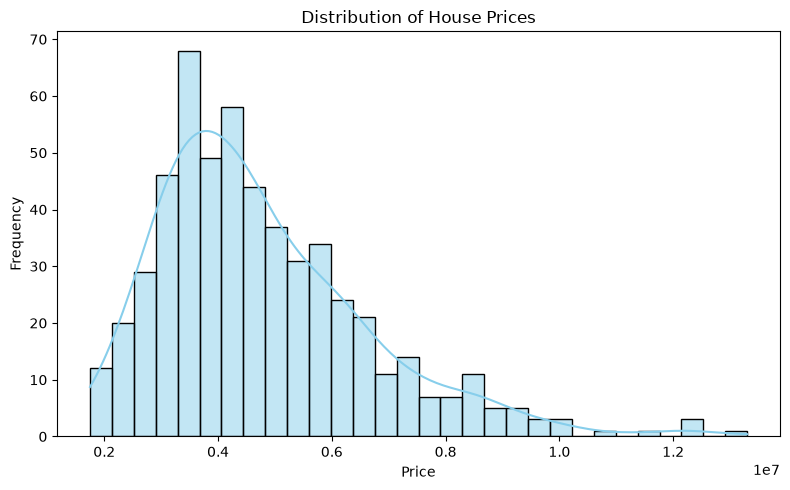

In [30]:
#Chart 1 – House Price Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("charts/house_price_distribution.png")

plt.show()

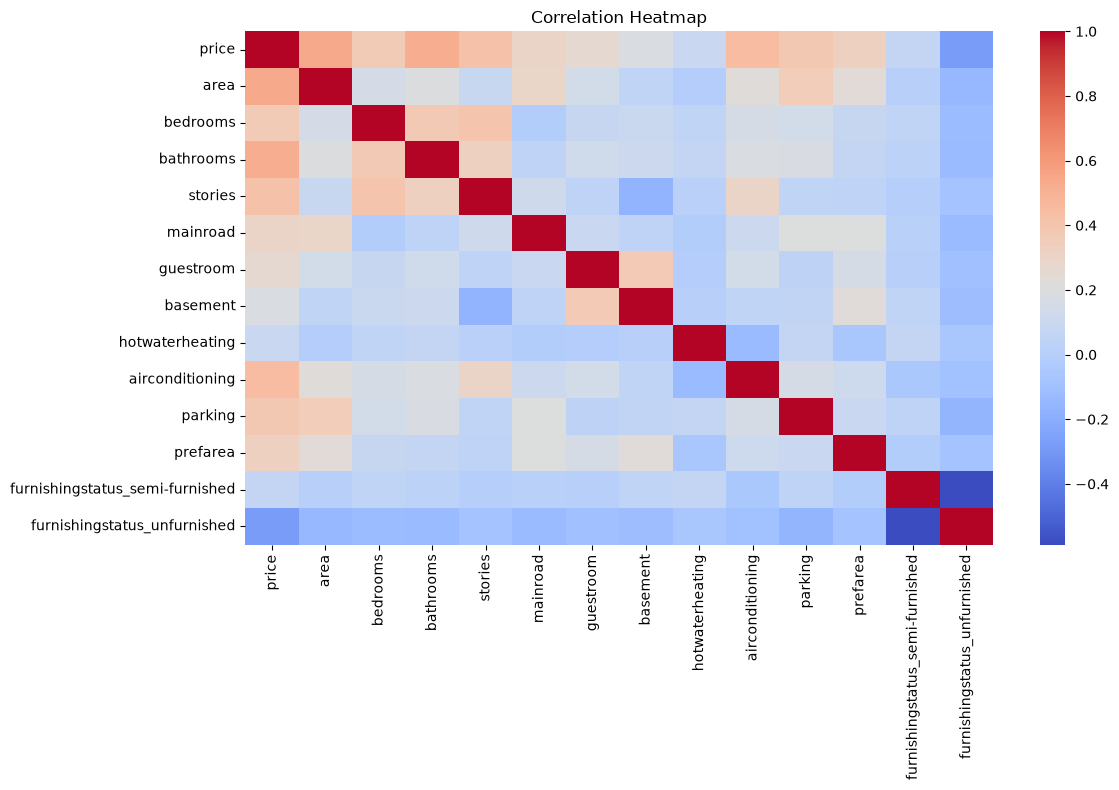

In [31]:
#Chart 2 – Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png")

plt.show()

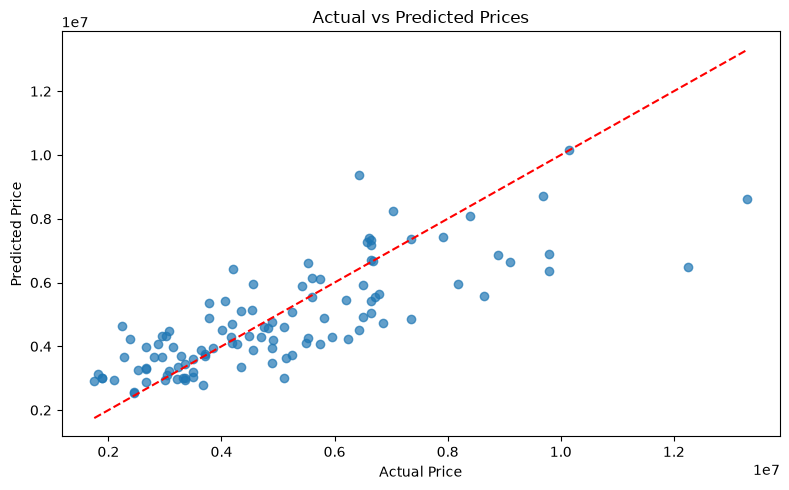

In [32]:
#Chart 3 – Actual vs Predicted
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.tight_layout()

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

,Feature,Importance
0,area,0.467809
2,bathrooms,0.152635
8,airconditioning,0.060260
9,parking,0.057557
3,stories,0.057045
1,bedrooms,0.047544
12,furnishingstatus_unfurnished,0.036974
6,basement,0.032418
10,prefarea,0.028316
7,hotwaterheating,0.018333


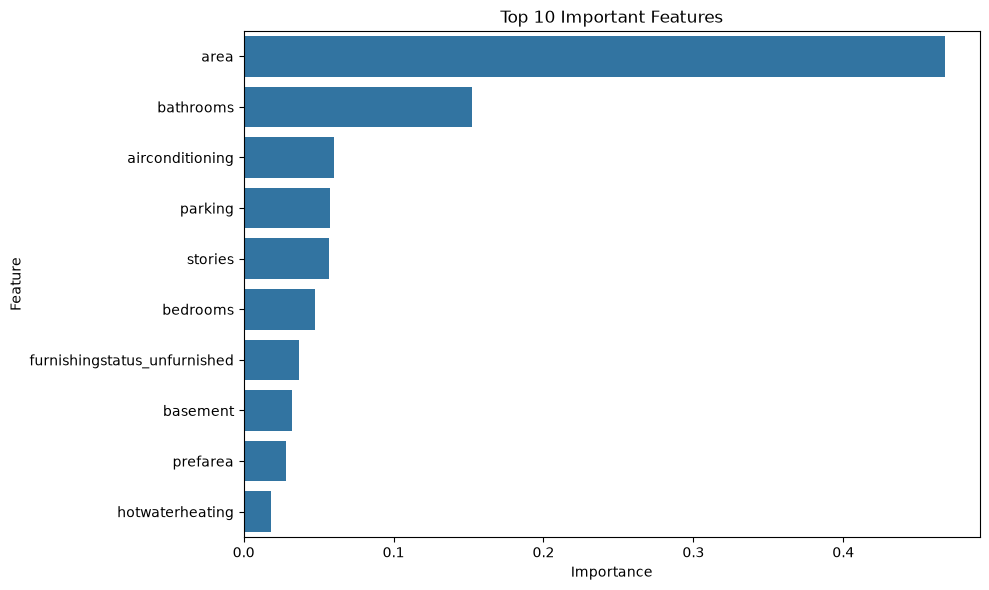

In [33]:
#Feature Importance Chart
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(10))

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.show()

# Insights & Summary

## Features Influencing House Prices
The analysis revealed that property area is the most influential factor affecting house prices. Other important factors include the number of bathrooms, bedrooms, stories, parking availability, and whether the property is located in a preferred area.

## Model Performance
Both Linear Regression and Random Forest Regressor achieved strong predictive performance. The high R² score indicates that the models successfully explain most of the variation in house prices, making them reliable for price estimation.

## Interesting Observation
One surprising finding was that property size has a much greater impact on price than luxury amenities such as air conditioning or hot water heating. The dataset also contains a small number of high-priced houses, creating a right-skewed distribution.

## Recommendation
Real estate businesses should focus on property area, location, and structural features when determining prices and designing marketing strategies. Homes with larger areas and preferred locations tend to command significantly higher market values.

## Conclusion
This project successfully developed machine learning models for house price prediction and identified the key factors driving property values. The results demonstrate how data analytics can support better pricing and investment decisions in the real estate industry.